# Entrega 3 - Maestría en Ciencia de Datos - UCU  
### Problema de abandono en banco - Competencia Kaggle  
#### Equipo: Enrique De Martini, Esteban Cardoso, Lucas Barrios  

## 0) Definiciones iniciales

### 0a) Importación de librerías generales

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
import joblib

### 0b) Definición de configuraciones generales

In [2]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

## 1) Procesamiento inicial

### 1a) Cargar datasets originales train.csv y test.csv

In [3]:
# 03. CARGAR DATASETS TRAIN.CSV Y TEST.CSV ---

# Cargamos dataset train.csv desde GitHub
url_train = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/train.csv"
df = pd.read_csv(url_train)

# Cargamos dataset test.csv desde GitHub
url_test = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/test.csv"
df_test = pd.read_csv(url_test)

# Guardamos id de test.csv para cuando debamos hacer el submission a Kaggle
test_ids = df_test["id"].copy()

### 1b) Realizar una inspección inicial del dataset original train.csv

In [4]:
print("AUDITORIA DE VARIABLES DEL DATASET TRAIN.CSV")

print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df.dtypes,
    'nulos':          df.isnull().sum(),
    'pct_nulos':      (df.isnull().sum() / len(df) * 100).round(2),
    'valores_únicos': df.nunique(),
    'moda':           df.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
display(audit)

AUDITORIA DE VARIABLES DEL DATASET TRAIN.CSV

Dimensiones del dataset: 15000 filas × 14 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
id,int64,0,0.00,15000,0,10134
CustomerId,float64,0,0.00,6309,15793331.00,15588923.00
Surname,object,0,0.00,763,Ch'iu,Chidiebere
CreditScore,float64,0,0.00,378,678.00,727.00
Geography,object,0,0.00,3,France,Spain
Gender,object,0,0.00,2,Male,Male
Age,float64,0,0.00,55,38.00,34.00
Tenure,float64,0,0.00,11,2.00,3.00
Balance,float64,0,0.00,3328,0.00,0.00
NumOfProducts,float64,0,0.00,4,2.00,2.00


### 1c) Depurar datasets originales train.csv y test.csv

In [5]:
# Eliminamos columnas que no se usarán en el modelo (identificadores)
col_eliminar =['id', 'CustomerId', 'Surname']

# Depuramos los datasets eliminando las columnas no deseadas
df = df.drop(columns=col_eliminar)
df_test = df_test.drop(columns=col_eliminar)

### 1d) Clasificar variables originales para tratamiento posterior

In [6]:
# Definimos variables numéricas a usar en el modelo
num_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Definimos variables categóricas a usar en el modelo
cat_features = [
    'Geography',
    'Gender',
    'NumOfProducts'
]

# Definimos variables binarias a usar en el modelo
bin_features = [
    'HasCrCard',
    'IsActiveMember'
]

# Definimos variable objetivo
target = 'Exited'

## 2) Análisis exploratorio de los datos del dataset original (EDA)

### 2a) Realizar estadística descriptiva del dataset train.csv depurado

In [7]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,658.13,37.74,5.00,42929.93,1.59,0.78,0.49,118535.94,0.20
std,73.26,8.18,2.81,59820.61,0.53,0.41,0.50,159223.34,0.40
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,600.00,32.00,3.00,0.00,1.00,1.00,0.00,82696.84,0.00
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,122964.18,0.00
75%,709.00,42.00,7.00,109733.20,2.00,1.00,1.00,156039.30,0.00
max,850.00,72.00,10.00,206329.65,4.00,1.00,1.00,18789543.34,1.00


### 2b) Realizar análisis de tasa de abandono versus variables categóricas y binarias (barplots)

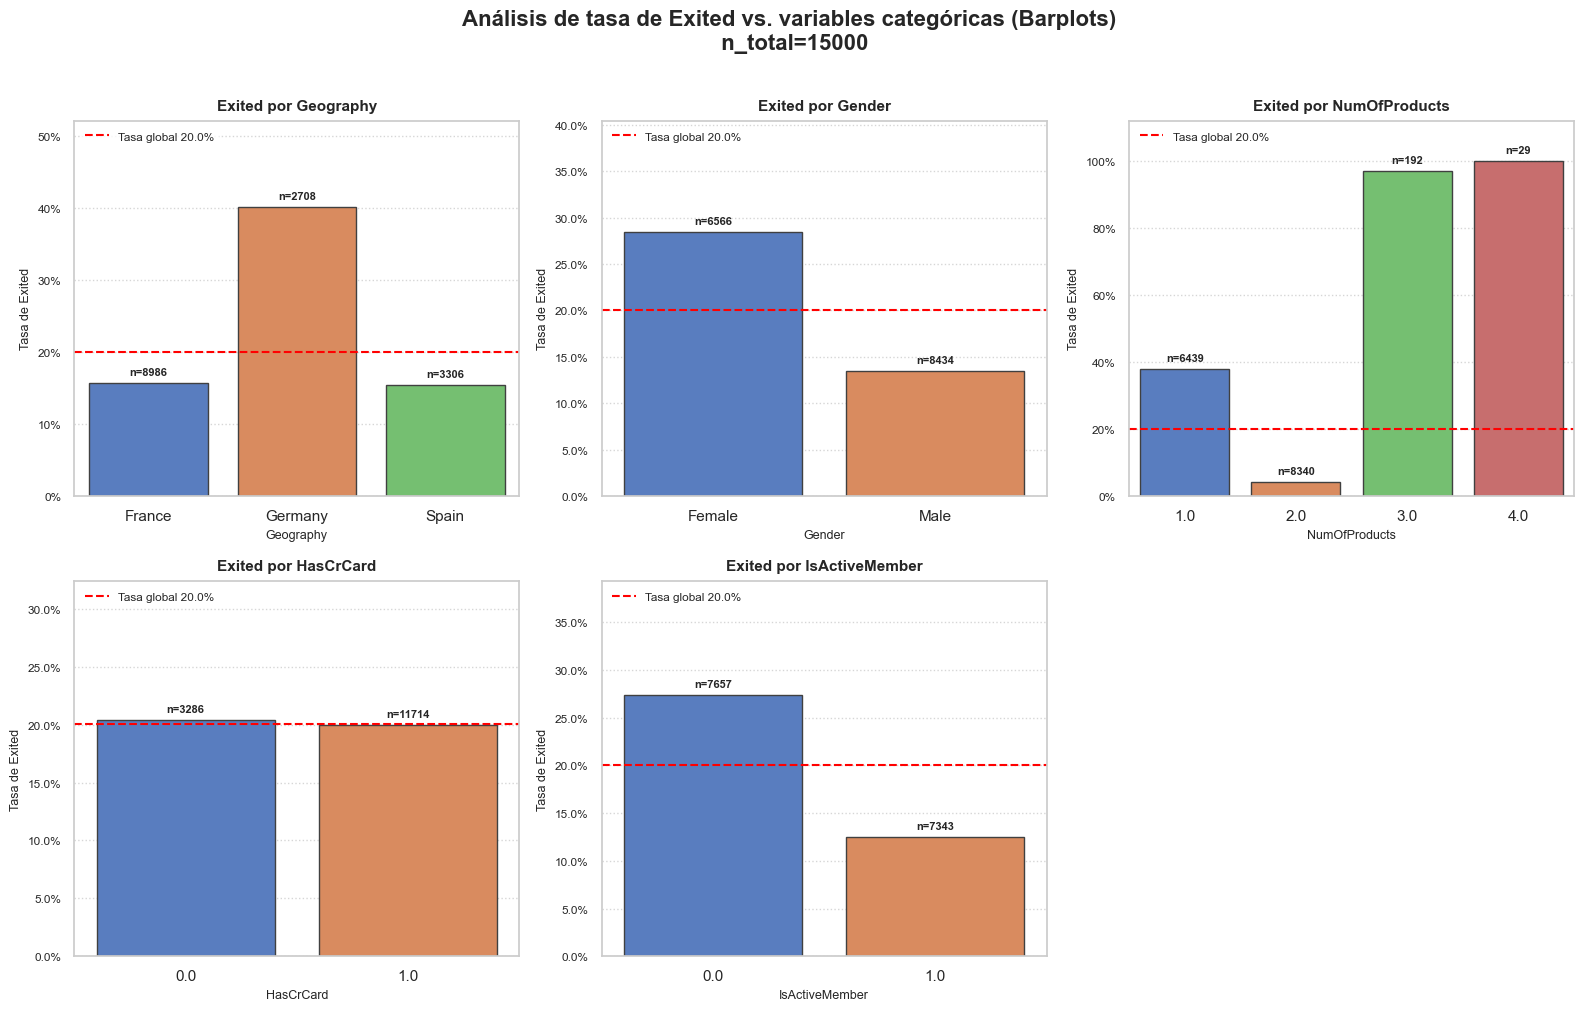

In [8]:
# Definimos las variables categóricas y binarias a analizar
variables_a_graficar = cat_features + bin_features

# Calculamos la tasa base real del dataset
tasa_base = df[target].mean()

# Configuramos el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Creamos una grilla de 2 filas y 3 columnas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes_flat = axes.flat

for i, var in enumerate(variables_a_graficar):
    ax = axes_flat[i]
    ax.grid(False)

    # Tasa de churn y tamaño muestral por categoría
    data_grafico = (
        df.groupby(var)[target]
        .agg(tasa='mean', n='size')
        .reset_index()
    )

    orden_categorias = data_grafico[var].tolist()

    sns.barplot(
        x=var,
        y='tasa',
        data=data_grafico,
        order=orden_categorias,
        hue=var,
        hue_order=orden_categorias,
        palette="muted",
        legend=False,
        edgecolor='#404040',
        ax=ax
    )

    linea_base = ax.axhline(
        y=tasa_base,
        color='red',
        linestyle='--',
        linewidth=1.5
    )

    ax.legend(
        [linea_base],
        [f'Tasa global {tasa_base*100:.1f}%'],
        loc='upper left',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='none'
    )

    ax.set_title(f"Exited por {var}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel("Tasa de Exited", fontsize=9)

    max_val = data_grafico['tasa'].max()
    ax.set_ylim(0, max_val + 0.12 if max_val > 0 else 0.3)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=8.5)
    ax.grid(axis='y', linestyle=':', alpha=0.8)

    # Etiquetas: solo tamaño muestral
    for j, p in enumerate(ax.patches):
        height = p.get_height()
        if height > 0 and j < len(data_grafico):
            n_cat = int(data_grafico.iloc[j]['n'])
            ax.annotate(
                f"n={n_cat}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=8,
                fontweight='bold'
            )

# Apagamos cuadrantes vacíos
for j in range(len(variables_a_graficar), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f"Análisis de tasa de Exited vs. variables categóricas (Barplots) \n n_total={len(df)}", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 2c) Realizar análisis de variables numéricas versus exited (boxplots)

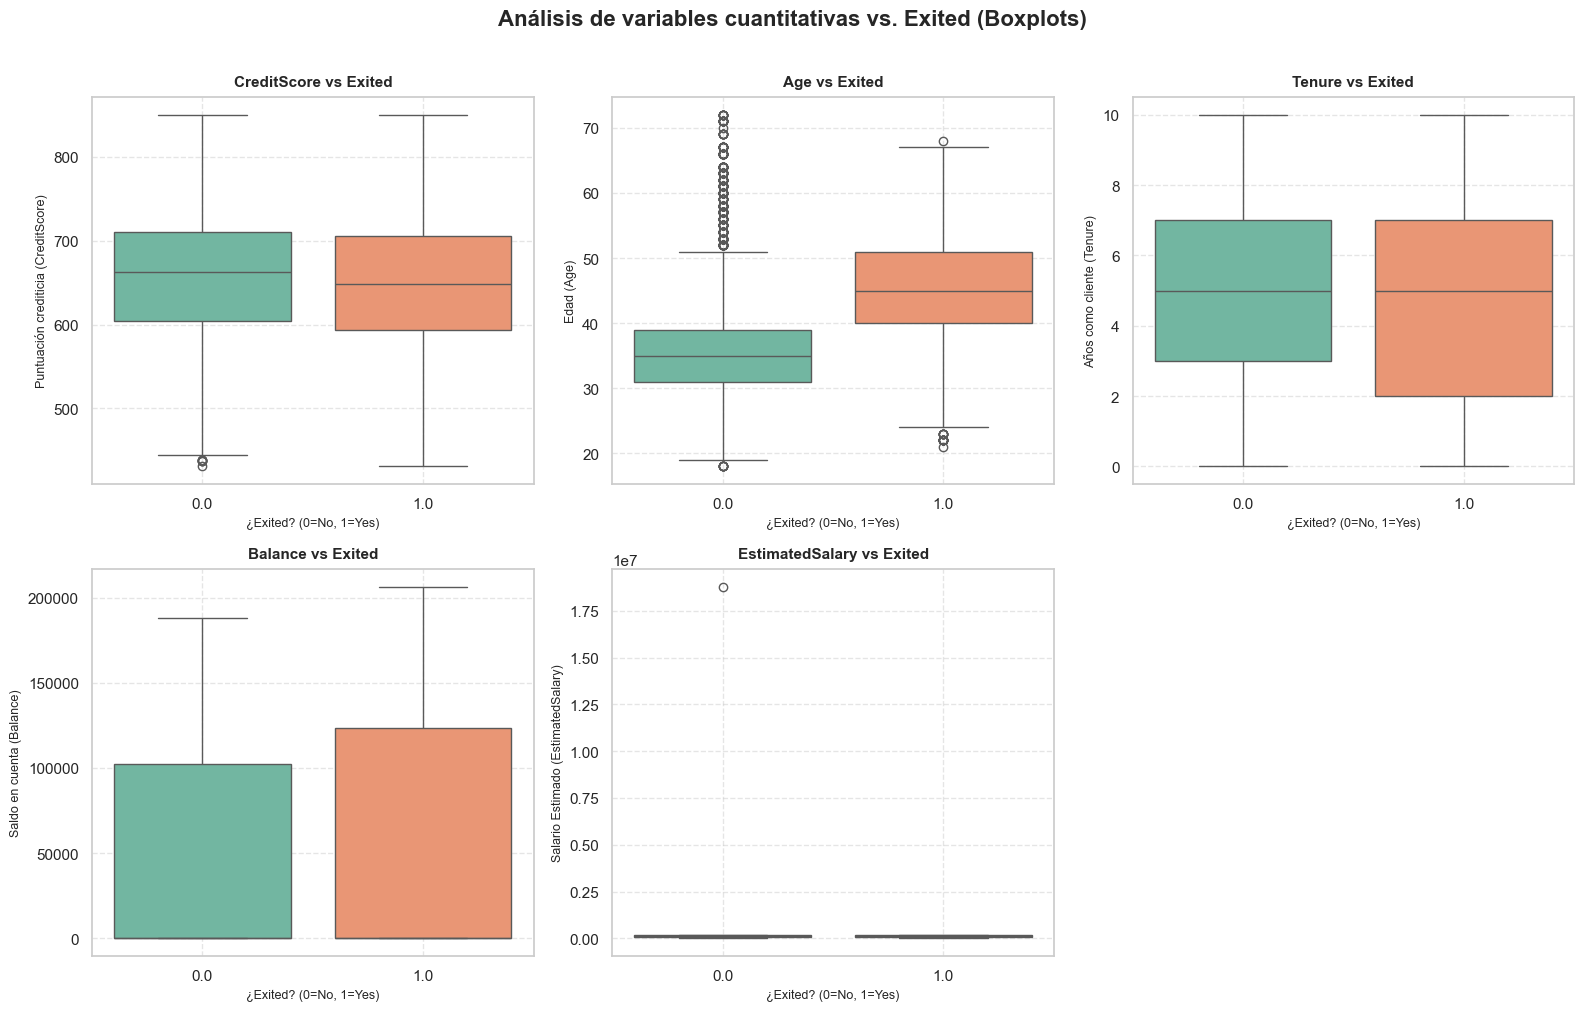

In [9]:
# Definimos las variables numéricas a analizar
variables_boxplot = num_features

# Configuramos el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Redefinimos el tamaño de la figura a un formato ideal (16 de base x 10 de alto)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# Aplanamos la matriz de 2x3 para iterar linealmente del 0 al 5
axes_flat = axes.flat

# Mapeamos títulos amigables en español
titulos = {
    'CreditScore': 'Puntuación crediticia (CreditScore)',
    'Age': 'Edad (Age)',
    'Tenure': 'Años como cliente (Tenure)',
    'Balance': 'Saldo en cuenta (Balance)',
    'EstimatedSalary': 'Salario Estimado (EstimatedSalary)'
}

# Iteramos para construir cada Boxplot
for i, var in enumerate(variables_boxplot):
    ax = axes_flat[i]

    sns.boxplot(
        x=target,
        y=var,
        data=df,
        ax=ax,
        palette="Set2",
        hue=target,
        legend=False
    )

    # Adaptamos títulos y etiquetas al ancho de las 2 columnas
    ax.set_title(f"{var} vs Exited", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("¿Exited? (0=No, 1=Yes)", fontsize=9)
    ax.set_ylabel(titulos.get(var, var), fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagamos cuadrantes vacíos
for j in range(len(variables_boxplot), len(axes_flat)):
    axes_flat[j].axis('off')

# Generamos título general, ajustamos layout y mostramos
plt.suptitle("Análisis de variables cuantitativas vs. Exited (Boxplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 2d) Realizar barplots de tasa de exited por rangos de variables numéricas

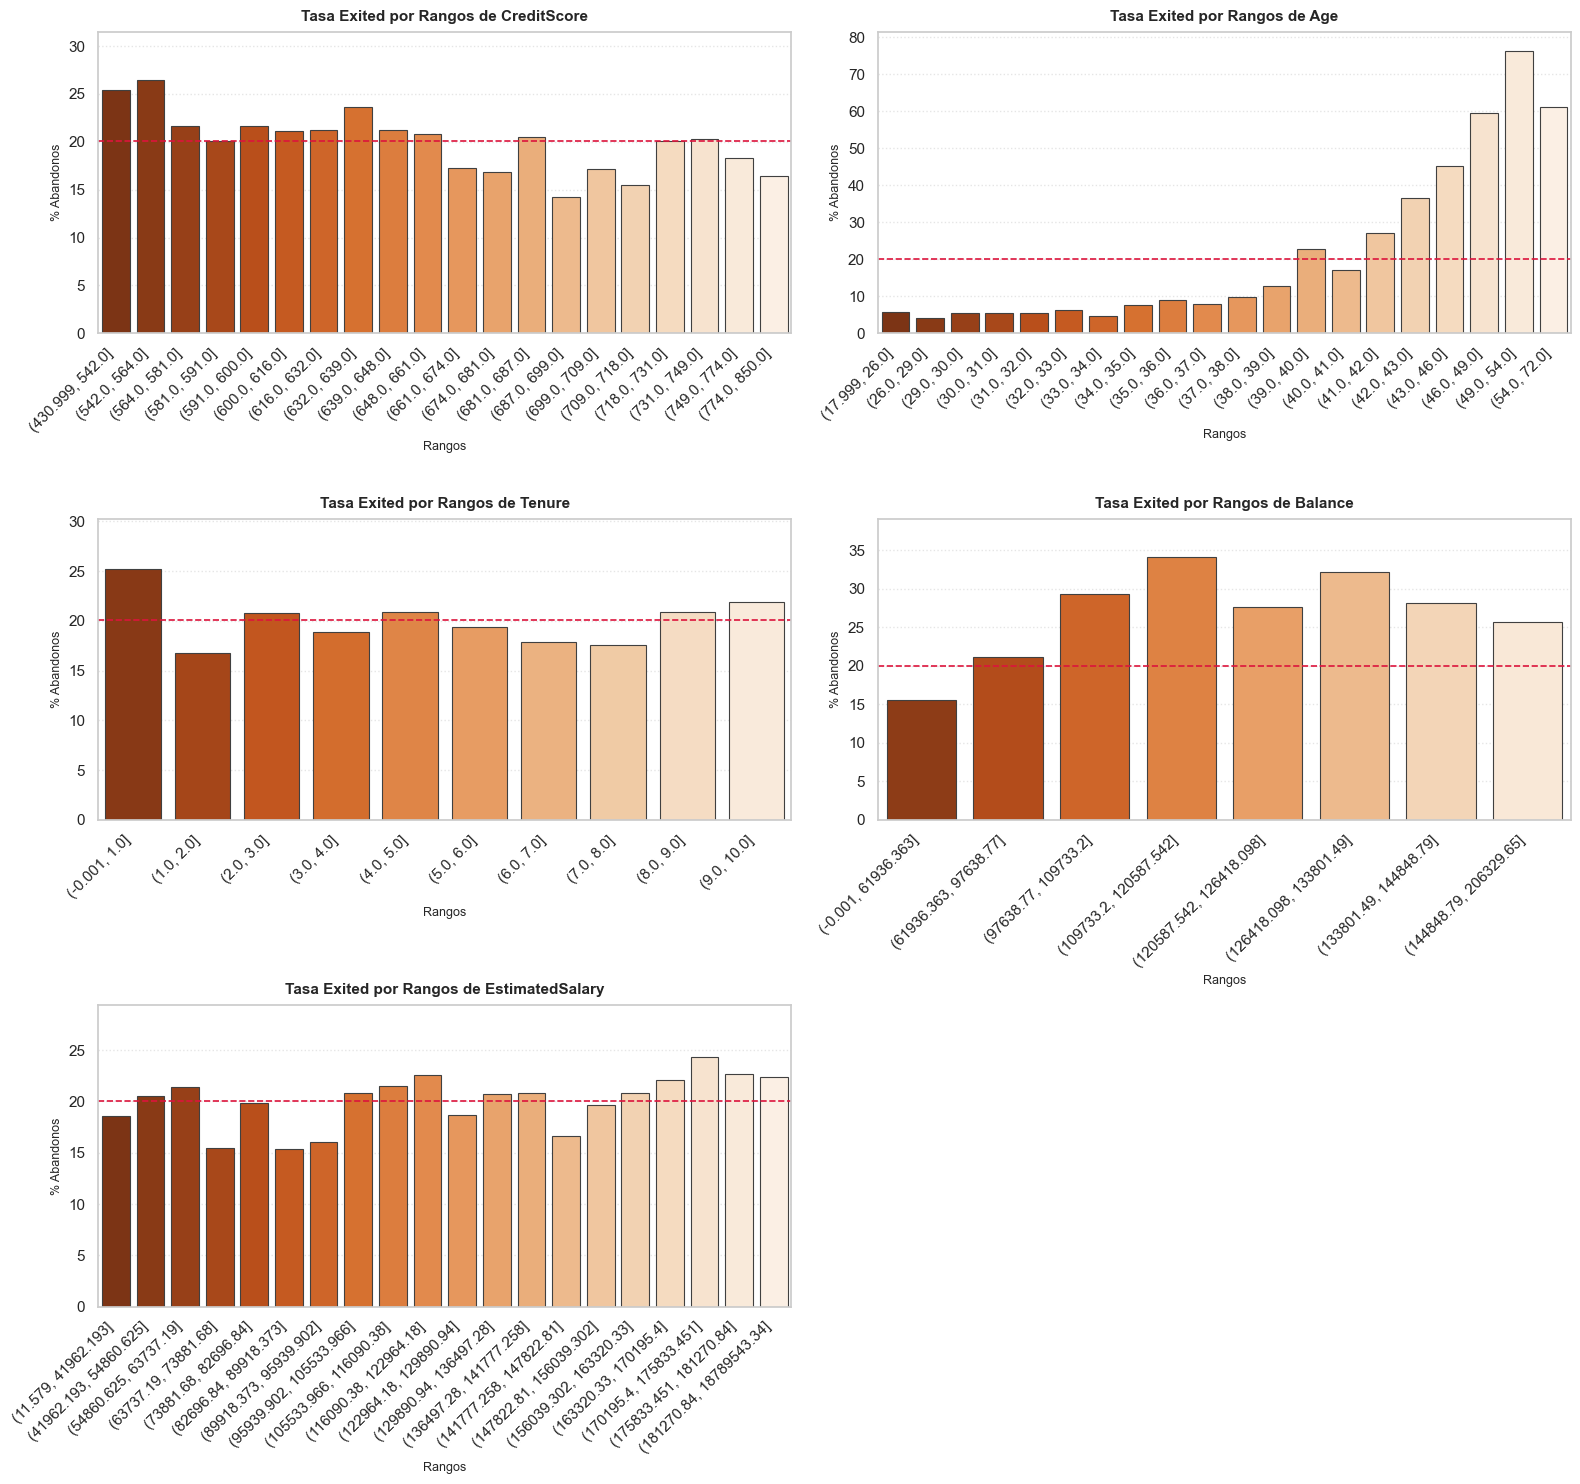

In [10]:
# Hacemos lo mismo pero para las variables numéricas, pero a estas las tendremos que dividir en rangos para los graficos de barras. 

n_cols = 2
# Calculamos las filas necesarias de forma dinámica
n_rows = math.ceil(len(num_features) / n_cols) 

# Creamos la copia de trabajo y pasamos el target a porcentaje directo (0 a 100%)
df_plot = df.copy()
df_plot['Exited_Percent'] = df_plot['Exited'].map({1: 100, 0: 0})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Aplanamos el array de ejes para poder iterar en un solo bucle limpio (aplasta una matriz 2D en 1D)
axes = axes.flatten()

# ==================================================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==================================================================================================
for i, var in enumerate(num_features):
    ax = axes[i]
    col_intervalo = f'{var}_Rango'
    
    # Segmentamos la variable numérica continua en 10 deciles
    # Usamos duplicates='drop' por seguridad si hay muchos valores idénticos (por lo que algunas variables no quedaran con 10 rangos)
    df_plot[col_intervalo] = pd.qcut(df_plot[var], q=20, duplicates='drop')

    data_tasa_num = (
        df_plot.groupby(col_intervalo, observed=True)['Exited_Percent']
        .mean()
        .sort_index()
        .reset_index()
    )

    data_tasa_num[col_intervalo] = data_tasa_num[col_intervalo].astype(str)
    
    # Dibujamos el barplot en el eje correspondiente
    sns.barplot(
        x=col_intervalo, 
        y='Exited_Percent', 
        data=data_tasa_num, 
        palette='Oranges_r',
        hue=col_intervalo,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )
    
    # Añadimos la línea roja con la tasa base del 16% global de la empresa
    ax.axhline(y=20.04, color='crimson', linestyle='--', linewidth=1.2, label='Base Global (20.04%)' if i == 0 else "")
    
    ax.set_title(f'Tasa Exited por Rangos de {var}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Rangos', fontsize=9) 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa_num['Exited_Percent'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

### 2e) Construir matriz de correlación (EDA solo numéricas) + ranking tornado

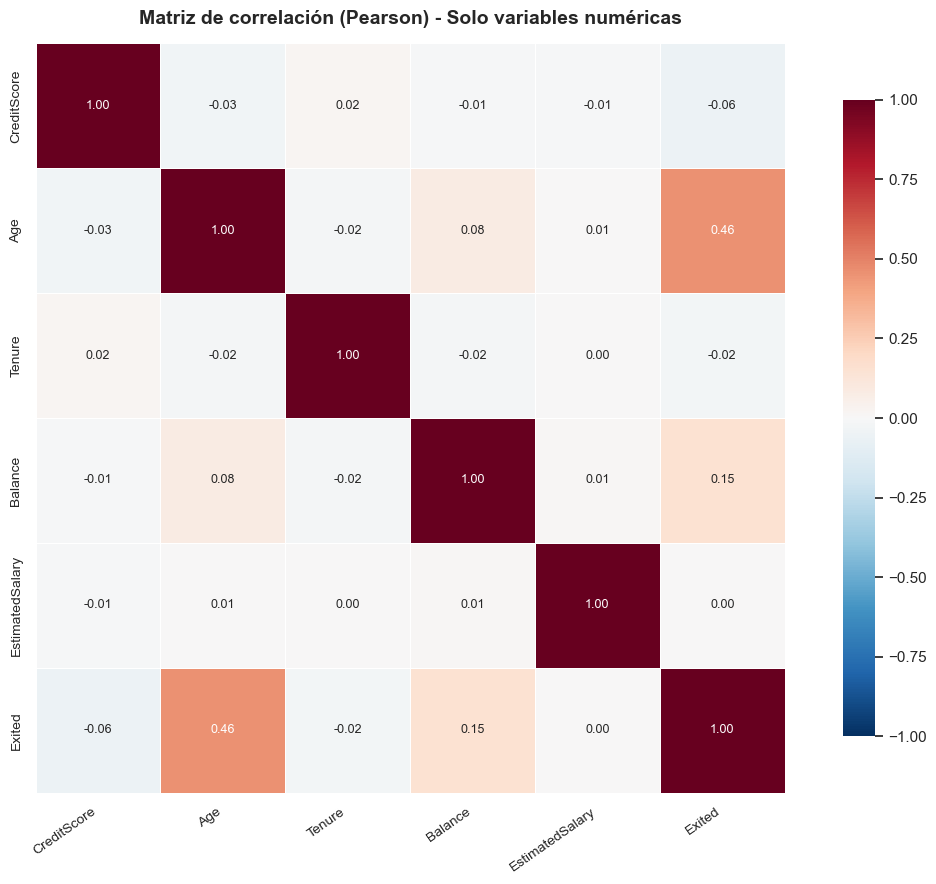

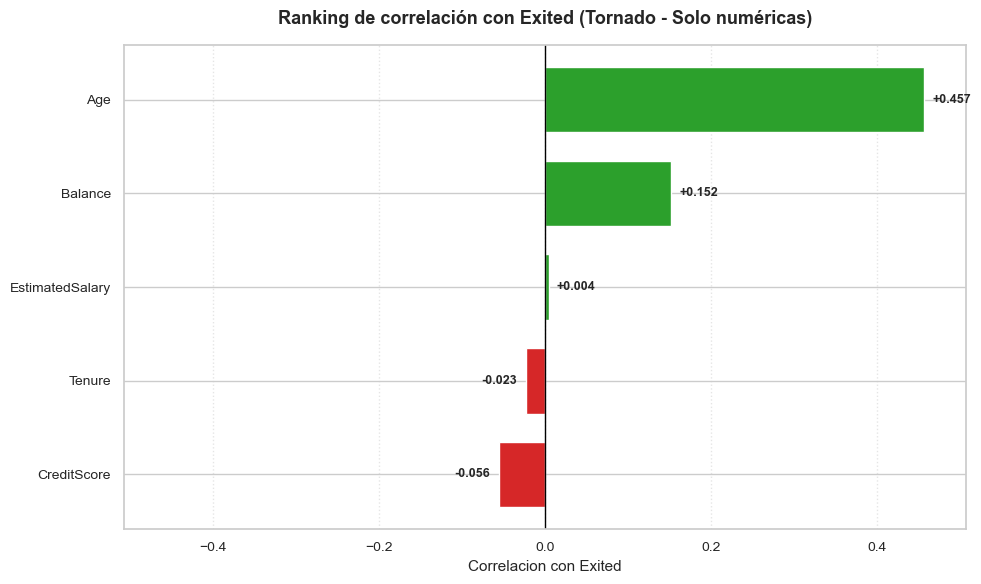

In [11]:
# Correlación solo con variables numericas del modelo + target
df_eda_corr_num = df[num_features + [target]].copy()
corr_eda = df_eda_corr_num.corr(numeric_only=True)

# Reordenar para dejar Exited al final (última fila y última columna)
if target in corr_eda.columns:
    cols_ordenadas = [c for c in corr_eda.columns if c != target] + [target]
    corr_eda = corr_eda.loc[cols_ordenadas, cols_ordenadas]

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_eda,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.85},
    annot_kws={'size': 9}
 )
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Matriz de correlación (Pearson) - Solo variables numéricas', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

# Ranking de correlación con el target en modo tornado
corr_target_eda = corr_eda[target].drop(target)

# Positivas arriba y negativas abajo
ranking_pos = corr_target_eda[corr_target_eda >= 0].sort_values(ascending=False)
ranking_neg = corr_target_eda[corr_target_eda < 0].sort_values(ascending=False)
ranking_eda = pd.concat([ranking_pos, ranking_neg])

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2ca02c' if v >= 0 else "#d62728" for v in ranking_eda.values]

ax.barh(ranking_eda.index, ranking_eda.values, color=colores, height=0.7)
ax.axvline(0, color='black', linewidth=1.0)
ax.invert_yaxis()
ax.set_xlabel('Correlacion con Exited', fontsize=11)
ax.set_title('Ranking de correlación con Exited (Tornado - Solo numéricas)', fontweight='bold', fontsize=13, pad=15)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

for i, v in enumerate(ranking_eda.values):
    offset = 0.01 if v >= 0 else -0.01
    align = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.3f}', va='center', ha=align, fontsize=9, fontweight='bold')

lim = max(abs(ranking_eda.min()), abs(ranking_eda.max())) + 0.05
ax.set_xlim(-lim, lim)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 3) Entrenar modelos con dataset original

### 3a) Random Forest con dataset original

#### 3a.1) Separar conjunto de entrenamiento y testeo

In [12]:
from sklearn.model_selection import train_test_split

# Obtenemos variables predictoras y variable objetivo
X = df.drop(columns=[target])
y = df[target]

# Obtenemos dataset de entrenamiento y testeo con dataset desbalanceado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # stratify=y porque dataset desbalanceado

#### 3a.2) Definir Column Transformer

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Imputamos por la mediana y escalamos las variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Imputamos por la moda y codificamos las variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Imputamos por la moda las variables binarias
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# Construimos el ColumnTransformer combinando los tres pipelines anteriores
preprocesador = ColumnTransformer(
    transformers=[
        ('escalar_num', numeric_transformer, num_features),
        ('codificar_cat', categorical_transformer, cat_features),
        ('imputar_bin', binary_transformer, bin_features),
    ],
    remainder='drop'
)

#### 3a.3) Entrenar modelo Random Forest con dataset original

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

pipe_rf = Pipeline(steps=[
    ('pre', preprocesador),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros (RF): {grid_rf.best_params_}")
print(f"Mejor ROC-AUC (RF):      {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (RF): {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Mejor ROC-AUC (RF):      0.9281


#### 3a.4) Evaluar mejor modelo Random Forest con dataset original

In [15]:
from sklearn.metrics import auc

y_pred = grid_rf.best_estimator_.predict(X_test)

auc = roc_auc_score(y_test, grid_rf.best_estimator_.predict_proba(X_test)[:, 1])
print(f"\n{'='*53}")
print(f"(ROC-AUC RF test = {auc:.4f})")
print(f"{'='*53}")
print(classification_report(y_test, y_pred))  


(ROC-AUC RF test = 0.9246)
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92      2399
         1.0       0.66      0.81      0.73       601

    accuracy                           0.88      3000
   macro avg       0.80      0.85      0.82      3000
weighted avg       0.89      0.88      0.88      3000



#### 3a.5) Construir matriz de confusión

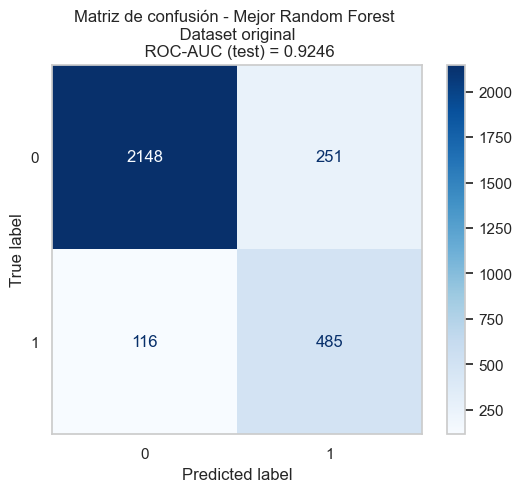

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_rf_model = grid_rf.best_estimator_

y_pred_best = best_rf_model.predict(X_test)
y_proba_best = best_rf_model.predict_proba(X_test)[:, 1]

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Mejor Random Forest \n Dataset original \n ROC-AUC (test) = {:.4f}'.format(roc_auc_score(y_test, y_proba_best)))
plt.grid(False)
plt.show()

### 3b) Red Neuronal con dataset original

In [17]:
# 11. BUSQUEDA DE HIPERPARAMETROS PARA MLP (CON BALANCEO SMOTE)

# ¡CAMBIO CRÍTICO!: Importamos Pipeline desde imblearn en lugar de sklearn para evitar data leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# 1. Pipeline integrado: Preprocesamiento -> Balanceo sintético -> Red Neuronal
nn_pipe = ImbPipeline(steps=[
    ('preprocesador', preprocesador),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),  # <- Aquí ocurre el balanceo dinámico
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

# 2. Grilla optimizada (eliminamos batch_sizes diminutos de 8 y 16, y arquitecturas erráticas)
param_dist = {
    'mlp__hidden_layer_sizes': [
        (32,), (64,), (128,),               # 1 capa oculta
        (64, 32), (128, 64), (32, 16),      # 2 capas en embudo
        (64, 64), (128, 128),               # 2 capas constantes
        (64, 32, 16), (32, 16, 8)           # 3 capas (límite máximo recomendado)
    ],
    'mlp__activation': ['relu'],
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'mlp__batch_size': [32, 64, 128, 256]   # Tamaños óptimos para velocidad en CPU
}

# 3. Búsqueda aleatoria respetando tus 20 iteraciones y 7 núcleos (n_jobs=7)
nn_search = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=7,
    verbose=1,
    random_state=42
)

# 4. Entrenamiento
nn_search.fit(X_train, y_train)

print('\nMejor AUC CV:', round(nn_search.best_score_, 4))
print('Mejores hiperparametros:')
for k, v in nn_search.best_params_.items():
    print(f'  - {k}: {v}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejor AUC CV: 0.9274
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.001
  - mlp__hidden_layer_sizes: (128,)
  - mlp__batch_size: 32
  - mlp__alpha: 0.1
  - mlp__activation: relu


AUC ROC (test) - mejor modelo: 0.9245

Classification Report (mejor modelo):
              precision    recall  f1-score   support

         0.0       0.96      0.84      0.90      2399
         1.0       0.58      0.86      0.69       601

    accuracy                           0.85      3000
   macro avg       0.77      0.85      0.79      3000
weighted avg       0.88      0.85      0.86      3000



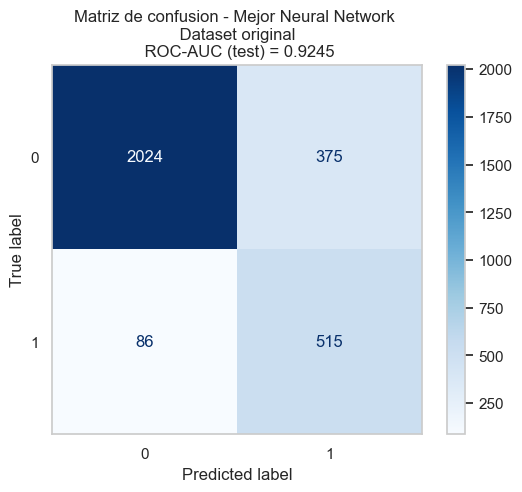

In [18]:
# 12. EVALUAR EL MEJOR MODELO EN TEST
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_nn_model = nn_search.best_estimator_

y_pred_best = best_nn_model.predict(X_test)
y_proba_best = best_nn_model.predict_proba(X_test)[:, 1]

print('AUC ROC (test) - mejor modelo:', round(roc_auc_score(y_test, y_proba_best), 4))
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Neural Network \n Dataset original \n ROC-AUC (test) = {:.4f}'.format(roc_auc_score(y_test, y_proba_best)))
plt.grid(False)
plt.show()

### 3c) Regresión Logistica 

In [19]:
# cargo librerias

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline_RL = Pipeline(steps=[
    ('preprocessor', preprocesador),
    ('modelo', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

param_grid_RL = {
    'modelo__C': [0.001,0.01,0.1, 1, 10, 100, 120, 150, 200, 250, 300, 350, 400, 450, 500],
}

grid_RL = GridSearchCV(
    pipeline_RL,
    param_grid_RL,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_RL.fit(X_train, y_train)
print('Mejor parámetro C:', grid_RL.best_params_)
print(f"Mejor ROC-AUC (LR):   {grid_RL.best_score_:.4f}"   )

Mejor parámetro C: {'modelo__C': 400}
Mejor ROC-AUC (LR):   0.9212


AUC ROC (test) - mejor modelo: 0.9168

Classification Report (mejor modelo):
              precision    recall  f1-score   support

         0.0       0.96      0.84      0.89      2399
         1.0       0.57      0.85      0.68       601

    accuracy                           0.84      3000
   macro avg       0.76      0.84      0.79      3000
weighted avg       0.88      0.84      0.85      3000



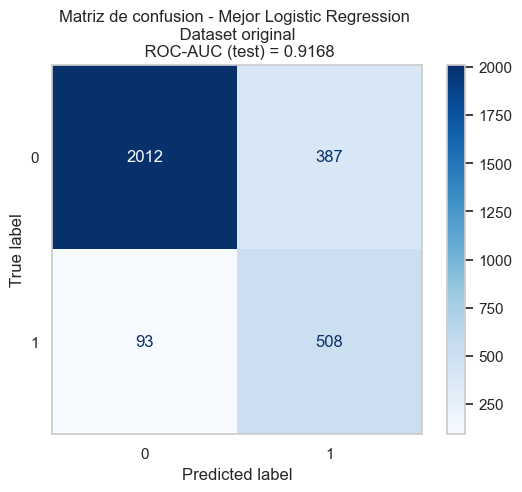

In [20]:
# 12. EVALUAR EL MEJOR MODELO EN TEST
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

model_RL = grid_RL.best_estimator_

y_pred_best = model_RL.predict(X_test)
y_proba_best = model_RL.predict_proba(X_test)[:, 1]

print('AUC ROC (test) - mejor modelo:', round(roc_auc_score(y_test, y_proba_best), 4))
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Logistic Regression \n Dataset original \n ROC-AUC (test) = {:.4f}'.format(roc_auc_score(y_test, y_proba_best)))
plt.grid(False)
plt.show()

## 4) Aplicación de técnicas de feature selection sobre dataset original

### 4a) Mutual information  
- Mutual information se basa en la entropía.  
- Mide cuánto disminuye la incertidumbre de la variable objetivo al conocer la variable predictora.  
- Detecta cualquier tipo de relación, ya sea lineal o no lineal.  
- Si el resultado es 0, las variables son estadísticamente independientes.

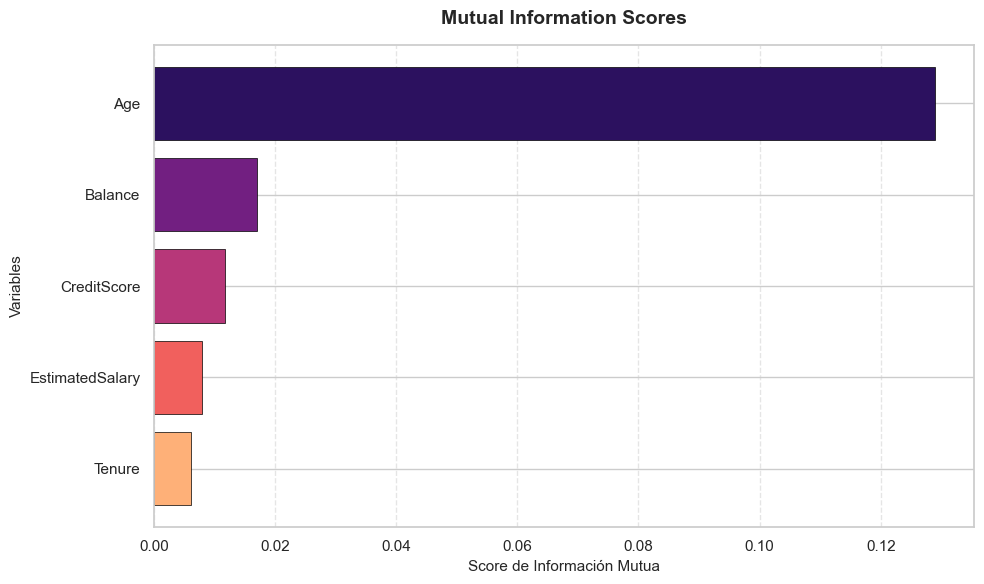

Ranking numérico de Mutual Information:


,Score
Age,0.13
Balance,0.02
CreditScore,0.01
EstimatedSalary,0.01
Tenure,0.01


In [21]:
from sklearn.feature_selection import mutual_info_classif

# Calculamos Mutual Information
mi = mutual_info_classif(X_train[num_features], y_train, random_state=42)
mi_scores = pd.Series(mi, index=num_features).sort_values(ascending=False)

# Configuramos la estética del gráfico
plt.figure(figsize=(10, 6))

# Visualización gráfico de mutual information
plt.barh(
    y=mi_scores.index,
    width=mi_scores.values,
    color=sns.color_palette('magma', len(mi_scores)),
    edgecolor='black',
    linewidth=0.5
)

# Invertimos eje Y para que la variable más importante esté arriba
plt.gca().invert_yaxis()

# Generamos títulos y etiquetas
plt.title('Mutual Information Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score de Información Mutua', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostramos la tabla exacta en pantalla
print("Ranking numérico de Mutual Information:")
display(mi_scores.to_frame(name='Score'))

### 4b) Permutation importance  
- El Permutation Importance es una técnica de evaluación de feature importance independiente del modelo.
- Si una variable es importante para las predicciones, al "romper" o alterar su información, el error del modelo debería aumentar drásticamente.
- El Permutation Importance se calcula sobre los datos de prueba (test set). 
- Dice qué tan importante es una variable para generalizar ante nuevos clientes, no solo para memorizar los datos de entrenamiento.

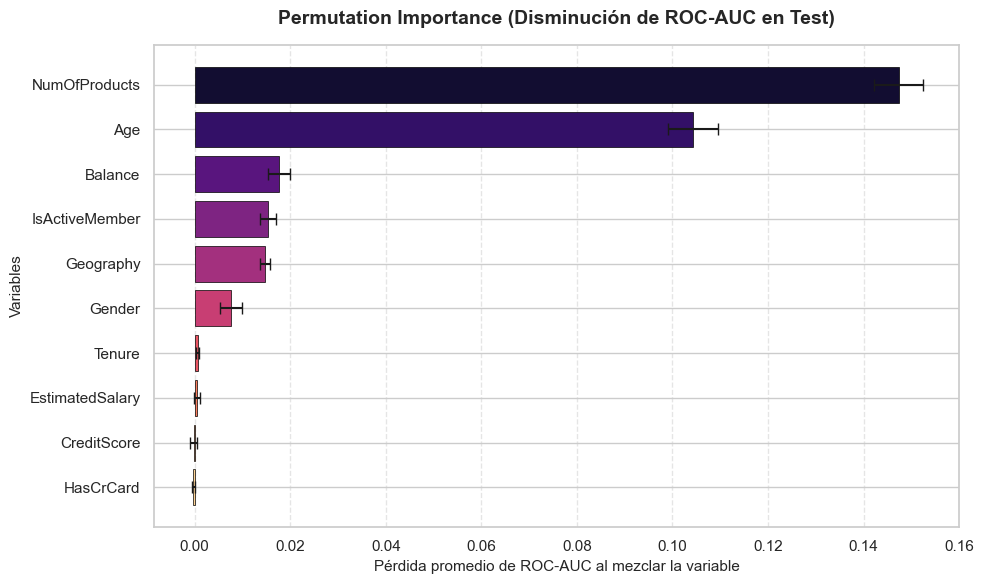

Ranking numérico de impacto:


,Variable,Importancia_Media,Desviacion_Estandar
6,NumOfProducts,0.15,0.01
3,Age,0.10,0.01
5,Balance,0.02,0.00
8,IsActiveMember,0.02,0.00
1,Geography,0.01,0.00
2,Gender,0.01,0.00
4,Tenure,0.00,0.00
9,EstimatedSalary,0.00,0.00
0,CreditScore,-0.00,0.00
7,HasCrCard,-0.00,0.00


In [22]:
from sklearn.inspection import permutation_importance

# Ejecutamos Permutation Importance
# Usamos el mejor modelo (best_estimator_) sobre los datos de prueba
resultado_permutacion = permutation_importance(
    estimator=grid_rf.best_estimator_,
    X=X_test,
    y=y_test,
    scoring='roc_auc',  # Usamos la misma métrica que en GridSearchCV
    n_repeats=10,       # Cantidad de veces que se mezcla cada columna para promediar
    random_state=42,
    n_jobs=-1           # Usa todos los procesadores disponibles
)

# Consolidamos los resultados en un DataFrame
df_importancia = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia_Media': resultado_permutacion.importances_mean,
    'Desviacion_Estandar': resultado_permutacion.importances_std
})

# Ordenamos las variables de mayor a menor importancia
df_importancia = df_importancia.sort_values(by='Importancia_Media', ascending=False)

# Visualizamos los resultados con un Barplot
plt.figure(figsize=(10, 6))

# Usamos matplotlib puro (plt.barh) que maneja perfectamente los errores pre-calculados (xerr)
plt.barh(
    y=df_importancia['Variable'],
    width=df_importancia['Importancia_Media'],
    xerr=df_importancia['Desviacion_Estandar'],
    capsize=4,
    color=sns.color_palette('magma', len(df_importancia)),
    edgecolor='black',
    linewidth=0.5
)

# Invertimos el eje Y para que la variable más importante quede en la parte superior
plt.gca().invert_yaxis()

plt.title('Permutation Importance (Disminución de ROC-AUC en Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pérdida promedio de ROC-AUC al mezclar la variable', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostrar la tabla exacta en pantalla
print("Ranking numérico de impacto:")
display(df_importancia)

### 4c) Feature importance  
- Visualiza la importancia intrínseca que el modelo de Random Forest le otorga a cada variable durante su entrenamiento.
- Lo que considera es la "Importancia basada en la impureza" (o Mean Decrease in Impurity - MDI)
- Un Random Forest está compuesto por muchos árboles de decisión.
- Cada vez que un árbol decide hacer un "corte" en una variable divide los datos en dos grupos más puros (con menos mezcla de clases).
- El algoritmo calcula cuánto "limpió" (o redujo la impureza de Gini) cada variable en cada nodo donde fue utilizada a lo largo de todos los árboles del bosque.
- La reducción de impureza se promedia para obtener un valor final.
- Si una variable redujo la incertidumbre mucho y muchas veces, tendrá una importancia alta.

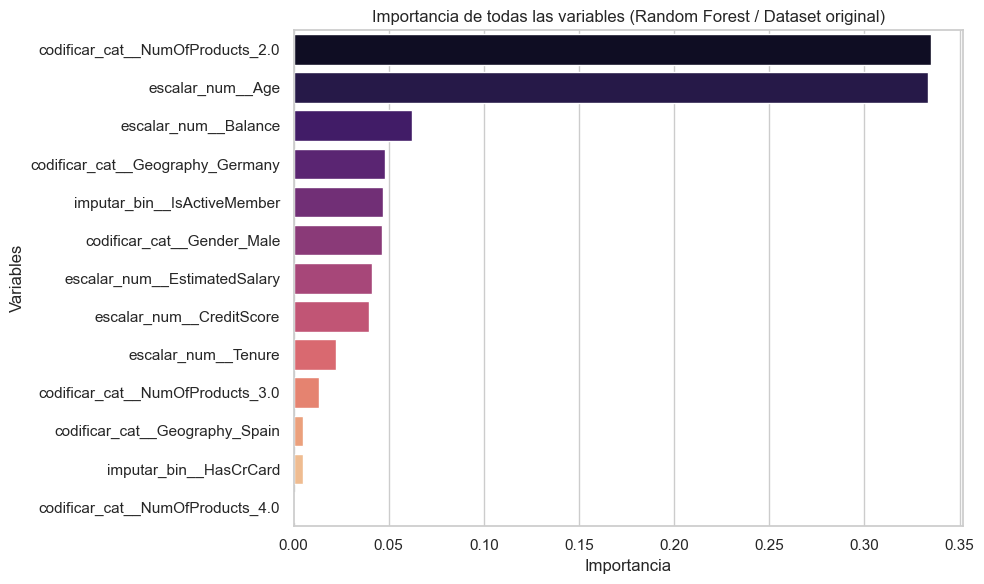

In [23]:
# Extraemos el modelo y el preprocesador del pipeline
modelo = grid_rf.best_estimator_.named_steps['clf']
preprocesador = grid_rf.best_estimator_.named_steps['pre']

# Obtenemos los nombres de las columnas tras el procesamiento
col_nombres = preprocesador.get_feature_names_out()

# 3. Obtenemos las importancias
importancias = modelo.feature_importances_

# Creamos el dataFrame de importancia y la ordenamos de mayor a menor
df_importancia = pd.DataFrame({'Variable': col_nombres, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Graficamos todas las variables (calculamos la altura dinámicamente según el número de variables)
plt.figure(figsize=(10, max(6, len(df_importancia) * 0.25)))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')
plt.title('Importancia de todas las variables (Random Forest / Dataset original)')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

## 5) Creación de nuevas variables que se agregarán al dataset original

Se crearán las siguientes nuevas variables sugeridas por el conocimiento experto para enriquecer el modelo Random Forest:  
  
- BalancePerProduct (Balance / NumOfProducts)  
- BalancePerTenure (Balance / (Tenure + 1))  
- EstimatedSalaryToBalanceRatio (EstimatedSalary / Balance)  
- CreditScore_x_IsActiveMember (CreditScore x IsActiveMember)  
- AgeGroup (Age: <30, 30-40, 40-50, +50)  
- TenureGroup (Tenure: 0-2, 3-5, 6-10, +10)  
- CreditScoreCategory (Credit Score: <580 Pobre, 580-670 Medio, 670-740 Bueno, +740 Excelente)  
- IsSeniorCitizen (Age > 60)  
- HasBalance (Balance > 0)  
- IsHighVolumeClient (NumOfProducts > 2)  
- IsHighValueCustomer (Balance > 100000 o EstimatedSalary > 120000)
- Age_x_CreditScore (Age x CreditScore)  
- Balance_x_IsActiveMember (Balance x IsActiveMember)  
- Tenure_x_HasCrCard (Tenure x HasCrCard)  
- Geography_x_Gender (Geography + '_' + Gender)  
- LogEstimatedSalary (log(EstimatedSalary))  
- LoyaltyIndex (0.5 x ('Tenure'/10) + 0.3 x 'IsActiveMember' + 0.2 x ('NumOfProducts'/4))

Se modificará el dataset de variables originales agregando las indicadas anteriormente 

In [24]:
from sklearn.preprocessing import FunctionTransformer

def crear_nuevas_variables(X):
    X = X.copy()
    X['BalancePerProduct'] = X['Balance'] / (X['NumOfProducts'] + 0.1)
    X['BalancePerTenure'] = X['Balance'] / (X['Tenure'] + 1)
    X['EstimatedSalaryToBalanceRatio'] = X['EstimatedSalary'] / (X['Balance'] + 0.1)
    X['CreditScore_x_IsActiveMember'] = X['CreditScore'] * X['IsActiveMember']
    X['AgeGroup'] = pd.cut(
        X['Age'],
        bins=[0, 30, 40, 50, float('inf')],
        labels=['<30', '30-40', '40-50', '+50'],
        right=False
        )
    X['TenureGroup'] = pd.cut(
        X['Tenure'],
        bins=[0, 3, 6, 11, float('inf')],
        labels=['0-2', '3-5', '6-10', '+10'],
        )
    X['CreditScoreCategory'] = pd.cut(
        X['CreditScore'],
        bins=[0, 580, 670, 740, float('inf')],
        labels=['Pobre', 'Medio', 'Bueno', 'Excelente'],
        right=False
        ) # rangos definidos según indice FICO internacional
    X['IsSeniorCitizen'] = (X['Age'] > 60).astype(int)
    X['HasBalance'] = (X['Balance'] > 0).astype(int)
    X['IsHighVolumeClient'] = (X['NumOfProducts'] > 2).astype(int)
    X['IsHighValueCustomer'] = ((X['Balance'] > 100000) | (X['EstimatedSalary'] > 120000)).astype(int) # usamos sentencia OR
    X['Age_x_CreditScore'] = X['Age'] * X['CreditScore']
    X['Balance_x_IsActiveMember'] = X['Balance'] * X['IsActiveMember']
    X['Tenure_x_HasCrCard'] = X['Tenure'] * X['HasCrCard']
    X['Geography_x_Gender'] = X['Geography'].astype(str) + '_'+ X['Gender'].astype(str)
    X['LogEstimatedSalary'] = np.log1p(X['EstimatedSalary'])
    X['LoyaltyIndex'] = 0.5 * (X['Tenure'] / 10) + 0.3 * X['IsActiveMember'] + 0.2 * (X['NumOfProducts'] / 4)     
    return X

# Creamos el transformador de feature engineering usando FunctionTransformer
transformer_feature_eng = FunctionTransformer(crear_nuevas_variables)

## 6) Entrenamiento de los modelos con dataset modificado

### 6.1) Actualizar la lista de variables numéricas, categóricas y binarias para el modelo

In [25]:
# Actualizamos la lista de variables numéricas modificadas
num_features_modif = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary', 
    'BalancePerProduct',
    'BalancePerTenure',
    'EstimatedSalaryToBalanceRatio',
    'CreditScore_x_IsActiveMember',
    'Age_x_CreditScore',
    'Balance_x_IsActiveMember',
    'Tenure_x_HasCrCard',
    'LogEstimatedSalary',
    'LoyaltyIndex'
]

# Actualizamos la lista de variables categóricas modificadas
cat_features_modif = [
    'Geography',
    'Gender',
    'NumOfProducts',
    'AgeGroup',
    'TenureGroup',
    'CreditScoreCategory',
    'Geography_x_Gender'
    ]

# Actualizamos la lista de variables binarias modificadas
bin_features_modif = [
    'HasCrCard',
    'IsActiveMember',
    'IsSeniorCitizen',
    'HasBalance',
    'IsHighVolumeClient',
    'IsHighValueCustomer'    
    ]

### 6.2) Generar Column Transformer con nuevas variables creadas

In [26]:
# 22. ACTUALIZAR COLUMN TRANSFORMER CON NUEVAS VARIABLES

# Actualizamos el preprocesador con las nuevas variables
preprocesador_modif = ColumnTransformer(
    transformers=[
        ('escalar_num', numeric_transformer, num_features_modif),
        ('codificar_cat', categorical_transformer, cat_features_modif),
        ('imputar_bin', binary_transformer, bin_features_modif),
    ],
    remainder='drop'
)

### 6.3) Entrenar modelos con nuevas variables (todas) 

#### 6.3a) Random Forest con dataset modif 

In [27]:
# Agregamos el transformador de feature engineering al pipeline antes del preprocesador
pipe_rf_modif = Pipeline(steps=[
    ('fe', transformer_feature_eng),
    ('pre', preprocesador_modif),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced']
}

grid_rf_modif = GridSearchCV(
    estimator=pipe_rf_modif,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf_modif.fit(X_train, y_train)

print(f"Mejores parámetros (RF): {grid_rf_modif.best_params_}")
print(f"Mejor ROC-AUC (RF):      {grid_rf_modif.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (RF): {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
Mejor ROC-AUC (RF):      0.9266


In [28]:
from sklearn.metrics import auc

y_pred = grid_rf_modif.best_estimator_.predict(X_test)

auc = roc_auc_score(y_test, grid_rf_modif.best_estimator_.predict_proba(X_test)[:, 1])
print(f"\n{'='*53}")
print(f"(ROC-AUC RF test = {auc:.4f})")
print(f"{'='*53}")
print(classification_report(y_test, y_pred))


(ROC-AUC RF test = 0.9217)
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92      2399
         1.0       0.67      0.78      0.72       601

    accuracy                           0.88      3000
   macro avg       0.81      0.84      0.82      3000
weighted avg       0.89      0.88      0.88      3000



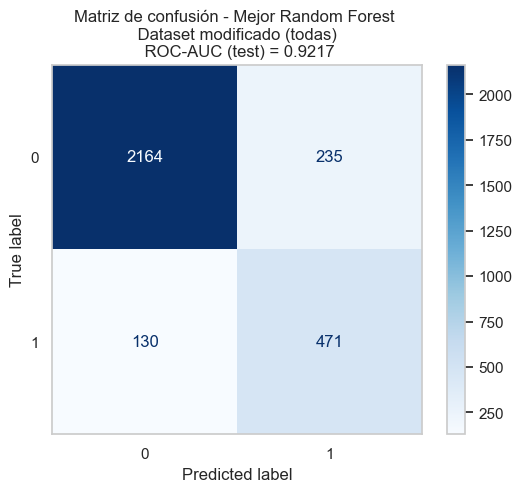

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_rf_model_modif = grid_rf_modif.best_estimator_

y_pred_best_modif = best_rf_model_modif.predict(X_test)
y_proba_best_modif = best_rf_model_modif.predict_proba(X_test)[:, 1]

cm_best = confusion_matrix(y_test, y_pred_best_modif)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Mejor Random Forest \n Dataset modificado (todas) \n ROC-AUC (test) = {:.4f}'.format(roc_auc_score(y_test, y_proba_best_modif)))
plt.grid(False)
plt.show()

#### 6.3a) Red Neuronal con dataset modif 

In [30]:
# 11. BUSQUEDA DE HIPERPARAMETROS PARA MLP

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
# ¡IMPORTANTE! Importamos el Pipeline desde imblearn, NO desde sklearn
from imblearn.pipeline import Pipeline as ImbPipeline


# 2. Creamos el nuevo pipeline usando ImbPipeline e insertando el paso de SMOTE
nn_pipe_modif = ImbPipeline(steps=[
    ('fe', transformer_feature_eng),
    ('preprocesador', preprocesador_modif),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),  # Crea ejemplos sintéticos de la clase minoritaria
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

param_dist_modif = {
    # Diseños optimizados para 39 entradas (iniciando con 64 o 128 neuronas)
    'mlp__hidden_layer_sizes': [
        (64,), (128,),                     # 1 capa: Rápidas, excelente base en tabulares
        (64, 32), (128, 64), (128, 32),    # 2 capas en embudo: Compresión progresiva
        (64, 64), (128, 128),              # 2 capas constantes: Mayor capacidad de abstracción
        (128, 64, 32), (64, 32, 16)        # 3 capas: Límite máximo de profundidad recomendado
    ],
    'mlp__activation': ['relu'],
    
    # Penalización L2 para controlar la colinealidad típica de 39 variables
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    
    # Tasas de aprendizaje estándar y estables para Adam
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    
    # Lotes de tamaño medio-grande para aprovechar mejor la memoria y la CPU
    'mlp__batch_size': [32, 64, 128, 256]
}


from sklearn.model_selection import RandomizedSearchCV

nn_search_modif = RandomizedSearchCV(
    estimator=nn_pipe_modif,               # Tu pipeline con preprocesador + MLP
    param_distributions=param_dist_modif,
    n_iter=50,                        # Prueba solo 50 combinaciones al azar (muy efectivo)
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)



nn_search_modif.fit(X_train, y_train)

print('Mejor AUC CV:', round(nn_search_modif.best_score_, 4))
print('Mejores hiperparametros:')
for k, v in nn_search_modif.best_params_.items():
    print(f'  - {k}: {v}')

# tiempo de corrida casi 7 min (lucas)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor AUC CV: 0.9271
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.001
  - mlp__hidden_layer_sizes: (64,)
  - mlp__batch_size: 256
  - mlp__alpha: 1
  - mlp__activation: relu


AUC ROC (test) - mejor modelo: 0.9238

Classification Report (mejor modelo):
              precision    recall  f1-score   support

         0.0       0.96      0.86      0.91      2399
         1.0       0.60      0.84      0.70       601

    accuracy                           0.86      3000
   macro avg       0.78      0.85      0.80      3000
weighted avg       0.89      0.86      0.86      3000



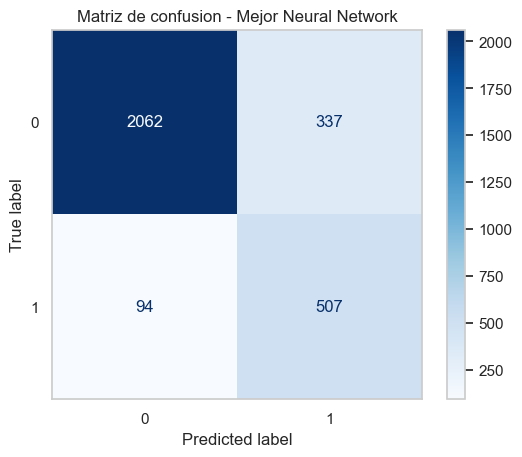

In [31]:
# 12. EVALUAR EL MEJOR MODELO EN TEST
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_nn_model = nn_search_modif.best_estimator_

y_pred_best = best_nn_model.predict(X_test)
y_proba_best = best_nn_model.predict_proba(X_test)[:, 1]

print('AUC ROC (test) - mejor modelo:', round(roc_auc_score(y_test, y_proba_best), 4))
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Neural Network')
plt.grid(False)
plt.show()

#### 6.3a) Regresion Logistica con dataset modif 

In [32]:
# cargo librerias

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


pipeline_RL_modif = Pipeline(steps=[
    ('fe', transformer_feature_eng),
    ('pre', preprocesador_modif),
    ('modelo', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

param_grid_RL_modif = {
    'modelo__C': [0.001,0.01,0.1, 1, 10, 100, 120, 150, 200, 250, 300, 350, 400, 450, 500],
}

grid_RL_modif = GridSearchCV(
    pipeline_RL_modif,
    param_grid_RL_modif,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_RL_modif.fit(X_train, y_train)
print('Mejor parámetro C:', grid_RL_modif.best_params_)
print(f"Mejor ROC-AUC (LR):   {grid_RL_modif.best_score_:.4f}"   )

Mejor parámetro C: {'modelo__C': 400}
Mejor ROC-AUC (LR):   0.9290


AUC ROC (test) - mejor modelo: 0.9219

Classification Report (mejor modelo):
              precision    recall  f1-score   support

         0.0       0.95      0.84      0.89      2399
         1.0       0.57      0.84      0.68       601

    accuracy                           0.84      3000
   macro avg       0.76      0.84      0.79      3000
weighted avg       0.88      0.84      0.85      3000



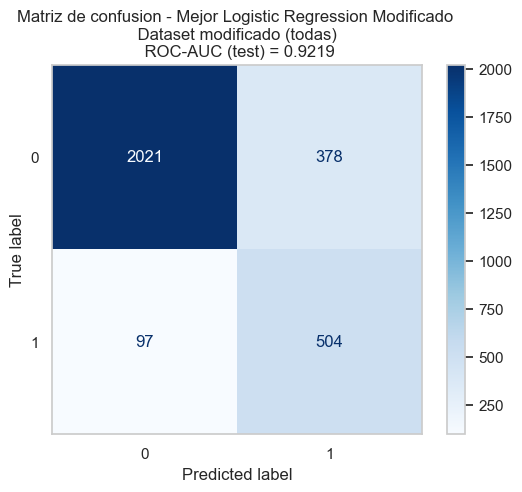

In [33]:
# 12. EVALUAR EL MEJOR MODELO EN TEST
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

model_RL_modif = grid_RL_modif.best_estimator_

y_pred_best = model_RL_modif.predict(X_test)
y_proba_best = model_RL_modif.predict_proba(X_test)[:, 1]

print('AUC ROC (test) - mejor modelo:', round(roc_auc_score(y_test, y_proba_best), 4))
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Logistic Regression Modificado \n Dataset modificado (todas) \n ROC-AUC (test) = {:.4f}'.format(roc_auc_score(y_test, y_proba_best)))
plt.grid(False)
plt.show()

## 7) Aplicación de técnicas de feature selection sobre dataset modificado

### 7a) Mutual information

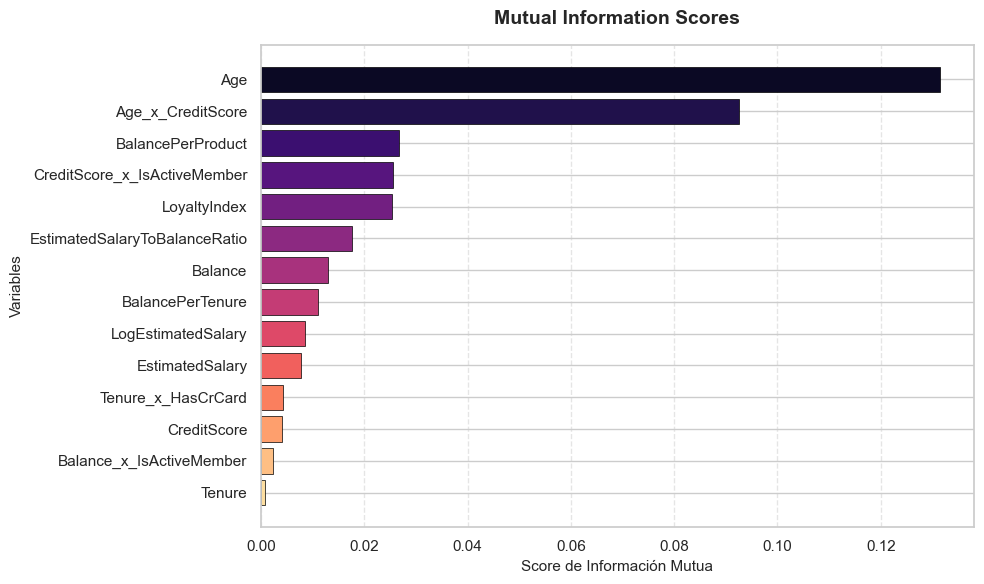

Ranking numérico de Mutual Information:


,Score
Age,0.13
Age_x_CreditScore,0.09
BalancePerProduct,0.03
CreditScore_x_IsActiveMember,0.03
LoyaltyIndex,0.03
EstimatedSalaryToBalanceRatio,0.02
Balance,0.01
BalancePerTenure,0.01
LogEstimatedSalary,0.01
EstimatedSalary,0.01


In [34]:
# Modificamos el dataset X_train para incluir las nuevas variables creadas
X_train_modif = crear_nuevas_variables(X_train)

# Calculamos Mutual Information
mi = mutual_info_classif(X_train_modif[num_features_modif], y_train, random_state=42)
mi_scores = pd.Series(mi, index=num_features_modif).sort_values(ascending=False)

# Configuramos la estética del gráfico
plt.figure(figsize=(10, 6))

# Visualización gráfico de mutual information
plt.barh(
    y=mi_scores.index,
    width=mi_scores.values,
    color=sns.color_palette('magma', len(mi_scores)),
    edgecolor='black',
    linewidth=0.5
)

# Invertimos eje Y para que la variable más importante esté arriba
plt.gca().invert_yaxis()

# Generamos títulos y etiquetas
plt.title('Mutual Information Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score de Información Mutua', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostramos la tabla exacta en pantalla
print("Ranking numérico de Mutual Information:")
display(mi_scores.to_frame(name='Score'))

### 7b) Permutation importance

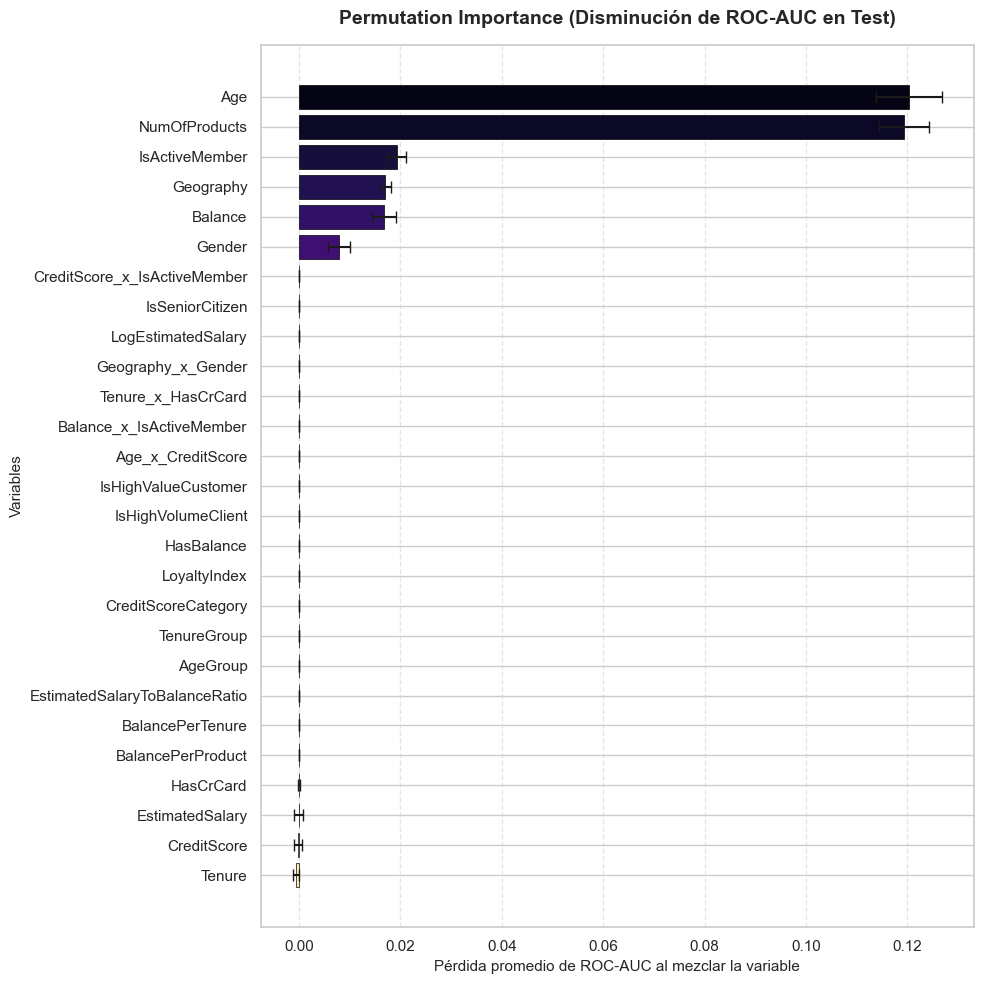

Ranking numérico de impacto:


,Variable,Importancia_Media,Desviacion_Estandar
3,Age,0.12,0.01
6,NumOfProducts,0.12,0.00
8,IsActiveMember,0.02,0.00
1,Geography,0.02,0.00
5,Balance,0.02,0.00
2,Gender,0.01,0.00
13,CreditScore_x_IsActiveMember,0.00,0.00
17,IsSeniorCitizen,0.00,0.00
25,LogEstimatedSalary,0.00,0.00
24,Geography_x_Gender,0.00,0.00


In [35]:
# Modificamos el dataset X_test para incluir las nuevas variables creadas
X_test_modif = crear_nuevas_variables(X_test)

# Ejecutamos Permutation Importance
# Usamos el mejor modelo (best_estimator_) sobre los datos de prueba
resultado_permutacion = permutation_importance(
    estimator=grid_rf_modif.best_estimator_,
    X=X_test_modif,
    y=y_test,
    scoring='roc_auc',  # Usamos la misma métrica que en GridSearchCV
    n_repeats=10,       # Cantidad de veces que se mezcla cada columna para promediar
    random_state=42,
    n_jobs=-1           # Usa todos los procesadores disponibles
)

# Consolidamos los resultados en un DataFrame
df_importancia = pd.DataFrame({
    'Variable': X_test_modif.columns,
    'Importancia_Media': resultado_permutacion.importances_mean,
    'Desviacion_Estandar': resultado_permutacion.importances_std
})

# Ordenamos las variables de mayor a menor importancia
df_importancia = df_importancia.sort_values(by='Importancia_Media', ascending=False)

# Visualizamos los resultados con un Barplot
plt.figure(figsize=(10, 10))

# Usamos matplotlib puro (plt.barh) que maneja perfectamente los errores pre-calculados (xerr)
plt.barh(
    y=df_importancia['Variable'],
    width=df_importancia['Importancia_Media'],
    xerr=df_importancia['Desviacion_Estandar'],
    capsize=4,
    color=sns.color_palette('magma', len(df_importancia)),
    edgecolor='black',
    linewidth=0.5
)

# Invertimos el eje Y para que la variable más importante quede en la parte superior
plt.gca().invert_yaxis()

plt.title('Permutation Importance (Disminución de ROC-AUC en Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pérdida promedio de ROC-AUC al mezclar la variable', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostrar la tabla exacta en pantalla
print("Ranking numérico de impacto:")
display(df_importancia)

### 7c) Feature importance

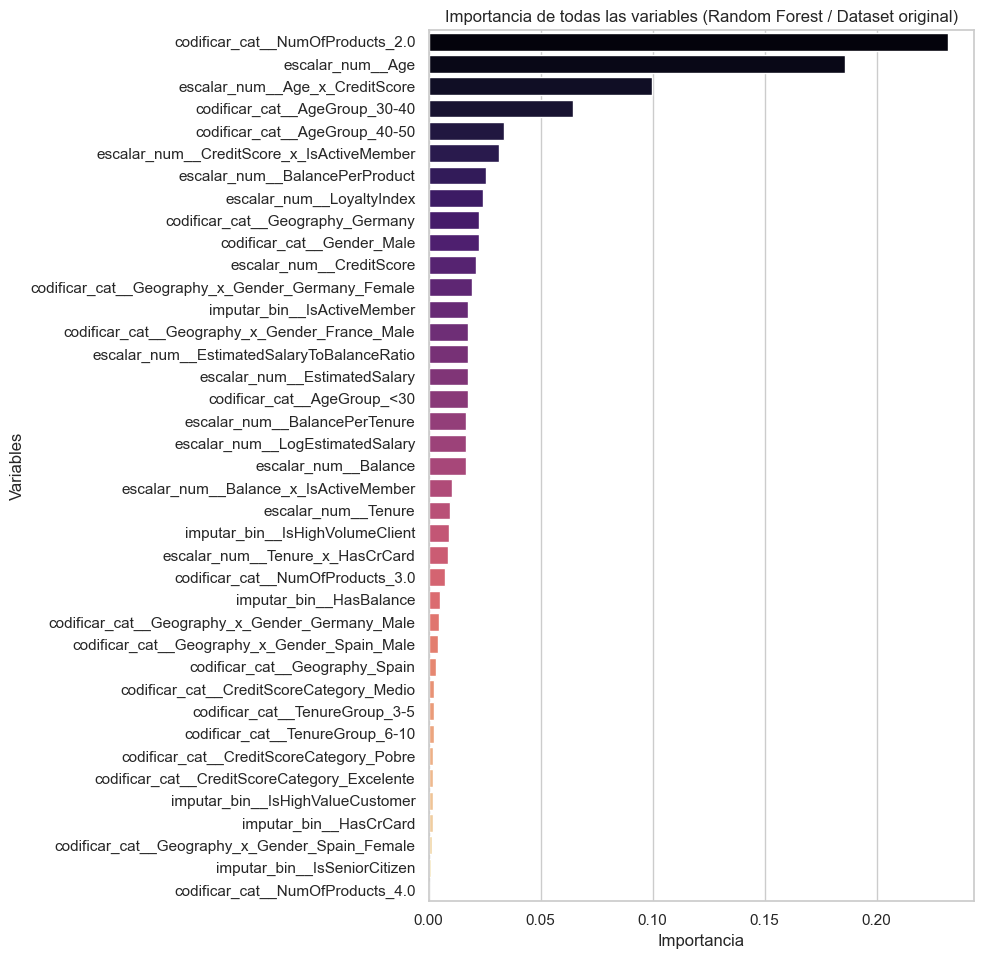

In [36]:
# Extraemos el modelo y el preprocesador del pipeline
modelo = grid_rf_modif.best_estimator_.named_steps['clf']
preprocesador = grid_rf_modif.best_estimator_.named_steps['pre']

# Obtenemos los nombres de las columnas tras el procesamiento
col_nombres = preprocesador.get_feature_names_out()

# 3. Obtenemos las importancias
importancias = modelo.feature_importances_

# Creamos el dataFrame de importancia y la ordenamos de mayor a menor
df_importancia = pd.DataFrame({'Variable': col_nombres, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Graficamos todas las variables (calculamos la altura dinámicamente según el número de variables)
plt.figure(figsize=(10, max(6, len(df_importancia) * 0.25)))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')
plt.title('Importancia de todas las variables (Random Forest / Dataset original)')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### 7.4a) RFECV para Random Forest

Los resultados en Random forest tambien se utilizaran para Red Nueronal. Por eso no existe una seccion 7.4b y se salta a la parte 7.4c que es la letra de Regresion Logistica 

Iniciando análisis RFECV (esto puede tomar unos minutos)...
Fitting estimator with 39 features.
Fitting estimator with 39 features.
Fitting estimator with 39 features.
Fitting estimator with 39 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 38 features.
Fitting estimator with 38 features.
Fitting estimator with 38 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 36 features.
Fitting estimator with 36 features.
Fitting estimator with 36 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 35 features.
Fitting estimator with 35 features.
Fitting estimator with 35 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitt

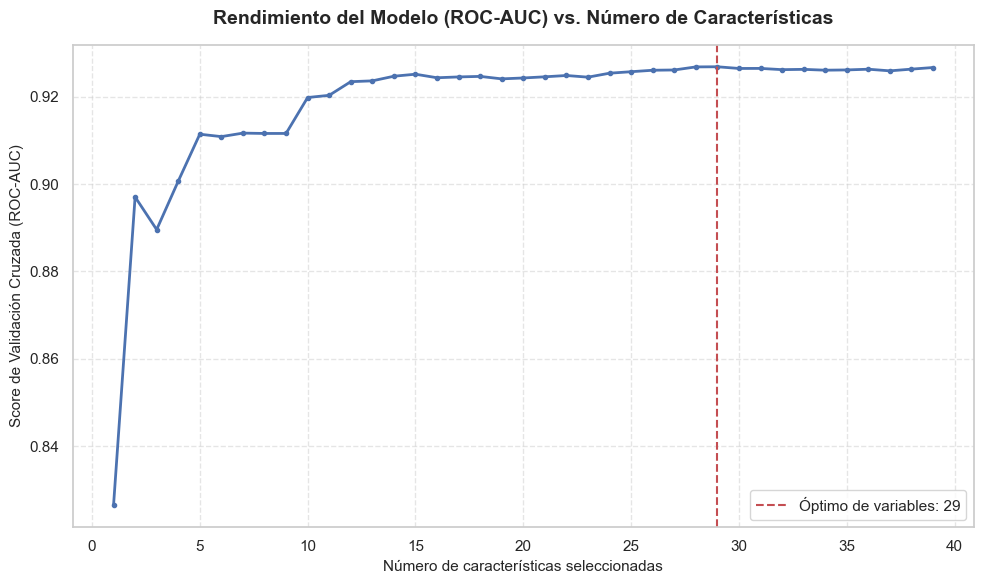


Ranking de variables según RFE:


,Variable,Seleccionada,Ranking
0,escalar_num__CreditScore,True,1
34,imputar_bin__IsActiveMember,True,1
30,codificar_cat__Geography_x_Gender_Germany_Male,True,1
29,codificar_cat__Geography_x_Gender_Germany_Female,True,1
28,codificar_cat__Geography_x_Gender_France_Male,True,1
36,imputar_bin__HasBalance,True,1
22,codificar_cat__AgeGroup_<30,True,1
21,codificar_cat__AgeGroup_40-50,True,1
20,codificar_cat__AgeGroup_30-40,True,1
37,imputar_bin__IsHighVolumeClient,True,1



Cantidad de variables descartadas por RFE: 10


In [37]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

print("Iniciando análisis RFECV (esto puede tomar unos minutos)...")

# Definimos el estimador base usando los mejores hiperparámetros que ya encontraste en tu GridSearch
best_params = grid_rf_modif.best_params_
# Limpiamos los prefijos 'clf__' para pasarlos directamente al clasificador
clean_params = {k.replace('clf__', ''): v for k, v in best_params.items()}
base_clf = RandomForestClassifier(random_state=42, **clean_params)

# Creamos un pipeline intermedio que aplique el feature engineering y el preprocesamiento 
# para extraer las matrices transformadas y pasarlas a RFE
from sklearn.pipeline import Pipeline as SkPipeline
preprocessing_pipeline = SkPipeline(steps=[
    ('fe', grid_rf_modif.best_estimator_.named_steps['fe']),
    ('pre', grid_rf_modif.best_estimator_.named_steps['pre'])
])

# Transformamos X_train y X_test para trabajar directamente con las features procesadas (One-Hot, Scaled, etc.)
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# Recuperamos los nombres finales de las columnas post-preprocesamiento
feature_names_final = grid_rf_modif.best_estimator_.named_steps['pre'].get_feature_names_out()

# Configuramos RFECV utilizando la métrica ROC-AUC y validación cruzada de 5 folds
rfecv = RFECV(
    estimator=base_clf,
    step=1,                # Elimina de 1 en 1 variable por iteración (o pon ej. 0.05 para ir más rápido)
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Ajustamos RFECV con los datos procesados
rfecv.fit(X_train_processed, y_train)

print(f"\nNúmero óptimo de características a mantener: {rfecv.n_features_}")

# --- VISUALIZACIÓN GRÁFICA DE RFECV ---
plt.figure(figsize=(10, 6))
plt.title('Rendimiento del Modelo (ROC-AUC) vs. Número de Características', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de características seleccionadas', fontsize=11)
plt.ylabel('Score de Validación Cruzada (ROC-AUC)', fontsize=11)

# Graficamos la curva de desempeño con su desviación estándar
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    color='b',
    linewidth=2,
    marker='o',
    markersize=3
)

# Marcamos con una línea vertical el punto óptimo
plt.axvline(
    x=rfecv.n_features_, 
    color='r', 
    linestyle='--', 
    label=f'Óptimo de variables: {rfecv.n_features_}'
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- RANKING Y SELECCIÓN DE VARIABLES ---
# Creamos un DataFrame con el ranking de todas las variables
df_rfe_ranking = pd.DataFrame({
    'Variable': feature_names_final,
    'Seleccionada': rfecv.support_,
    'Ranking': rfecv.ranking_
})

# Ordenamos por ranking (1 significa que fueron seleccionadas como las mejores)
df_rfe_ranking = df_rfe_ranking.sort_values(by='Ranking', ascending=True)

print("\nRanking de variables según RFE:")
display(df_rfe_ranking)

# Variables que el modelo sugiere eliminar (Ranking > 1)
variables_a_eliminar = df_rfe_ranking[df_rfe_ranking['Seleccionada'] == False]['Variable'].tolist()
print(f"\nCantidad de variables descartadas por RFE: {len(variables_a_eliminar)}")

### 7.4c) RFECV para Regresion Logistica 

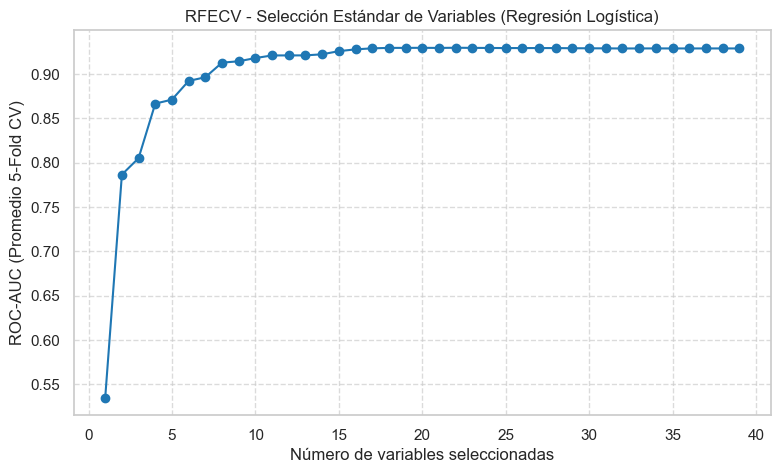

Número óptimo de variables: 22
Mejor ROC-AUC: 0.9297


In [38]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 1. Transformamos X_train con tu pipeline previo
pipe_transformacion = Pipeline(steps=[
    ('fe', transformer_feature_eng),
    ('pre', preprocesador_modif)
])
X_train_procesado = pipe_transformacion.fit_transform(X_train)

# 2. Configuración estándar de RFECV con el mejor C encontrado
modelo_lr = LogisticRegression(
    C=grid_RL_modif.best_params_['modelo__C'], 
    random_state=42, 
    class_weight='balanced', 
    max_iter=1000
)

rfecv_lr = RFECV(
    estimator=modelo_lr,
    step=1,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. Entrenamos
rfecv_lr.fit(X_train_procesado, y_train)

# 4. Gráfica estándar
plt.figure(figsize=(9, 5))
n_scores = len(rfecv_lr.cv_results_['mean_test_score'])
plt.plot(
    range(rfecv_lr.min_features_to_select, n_scores + rfecv_lr.min_features_to_select),
    rfecv_lr.cv_results_['mean_test_score'],
    marker='o',
    color='#1f77b4'
)

plt.title("RFECV - Selección Estándar de Variables (Regresión Logística)")
plt.xlabel("Número de variables seleccionadas")
plt.ylabel("ROC-AUC (Promedio 5-Fold CV)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Resultado oficial
print(f"Número óptimo de variables: {rfecv_lr.n_features_}")
print(f"Mejor ROC-AUC: {max(rfecv_lr.cv_results_['mean_test_score']):.4f}")

## 8) Reentrenamiento de los modelos final con variables seleccionadas por RFE

- Tomando el dataset original se entrenó un modelo de Random Forest y se obtuvo para el mejor modelo un ROC AUC en testing de 0.9246.  
- Se incluyó un conjunto de nuevas variables sugeridas del conocimiento del negocio y se volvió a entrenar un modelo de Random Forest con el dataset modificado. Para el mejor modelo se obtuvo un ROC AUC en testing de 0.9224.  
- La incoporación de muchas variables deterioró el modelo inicial, por lo que se llevó a cabo el análisis Recursive Feature Elimination (RFE), el cual sugiere acotar la cantidad de varibales a considerar al siguiente conjunto:  
    - CreditScore  
    - Age  
    - Tenure  
    - Balance  
    - EstimatedSalary   
    - BalancePerProduct  
    - BalancePerTenure  
    - EstimatedSalaryToBalanceRatio  
    - CreditScore_x_IsActiveMember  
    - Age_x_CreditScore  
    - Balance_x_IsActiveMember  
    - Tenure_x_HasCrCard  
    - LogEstimatedSalary  
    - LoyaltyIndex  
    - Geography'  
    - Gender  
    - NumOfProducts  
    - AgeGroup  
    - Geography_x_Gender  
    - IsActiveMember  
    - HasBalance  
    - IsHighVolumeClient
- Se procederá a entrenar un nuevo modelo de Random Forest final con estas variables.

#### 8a) Random Forest (dataset RFE)

##### 8a.1) Listar variables 

In [39]:
# Todas las numéricas pasaron el filtro (Ranking == 1)
num_features_final = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary', 
    'BalancePerProduct',
    'BalancePerTenure',
    'EstimatedSalaryToBalanceRatio',
    'CreditScore_x_IsActiveMember',
    'Age_x_CreditScore',
    'Balance_x_IsActiveMember',
    'Tenure_x_HasCrCard',
    'LogEstimatedSalary',
    'LoyaltyIndex'
]

# Se eliminaron las categorías de CreditScoreCategory y TenureGroup por bajo ranking
cat_features_final = [
    'Geography',
    'Gender',
    'NumOfProducts',
    'AgeGroup',
    'Geography_x_Gender'
]

# Se excluyeron HasCrCard e IsSeniorCitizen por tener un ranking desfavorable (> 1)
bin_features_final = [
    'IsActiveMember',
    'HasBalance',
    'IsHighVolumeClient'
]

##### 8a.2) Modificar Column Transformer para entrenar modelo Random Forest final

In [40]:
# Actualizamos el preprocesador con las nuevas variables
preprocesador_final = ColumnTransformer(
    transformers=[
        ('escalar_num', numeric_transformer, num_features_final),
        ('codificar_cat', categorical_transformer, cat_features_final),
        ('imputar_bin', binary_transformer, bin_features_final),
    ],
    remainder='drop'
)

##### 8a.3) Entrenar modelo Random Forest final con variables seleccionadas por RFE

In [41]:
# Agregamos el transformador de feature engineering al pipeline antes del preprocesador
pipe_rf_final = Pipeline(steps=[
    ('fe', transformer_feature_eng),
    ('pre', preprocesador_final),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced']
}

grid_rf_final = GridSearchCV(
    estimator=pipe_rf_final,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf_final.fit(X_train, y_train)

print(f"Mejores parámetros (RF): {grid_rf_final.best_params_}")
print(f"Mejor ROC-AUC (RF):      {grid_rf_final.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (RF): {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Mejor ROC-AUC (RF):      0.9268


##### 8a.4) Evaluar modelo Random Forest final con variables seleccionadas por RFE


(ROC-AUC RF test = 0.9237)
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92      2399
         1.0       0.67      0.79      0.73       601

    accuracy                           0.88      3000
   macro avg       0.81      0.85      0.83      3000
weighted avg       0.89      0.88      0.88      3000



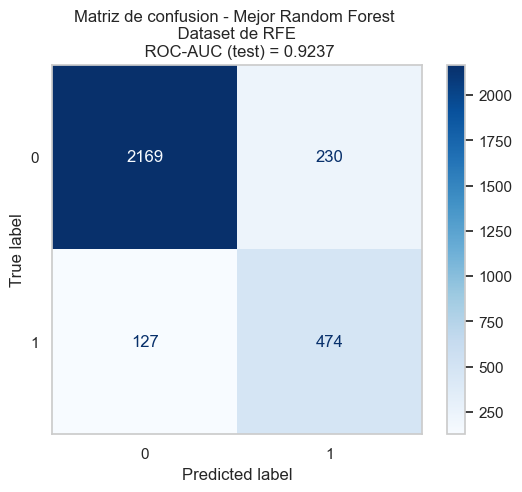

In [42]:
from sklearn.metrics import auc

y_pred = grid_rf_final.best_estimator_.predict(X_test)

auc = roc_auc_score(y_test, grid_rf_final.best_estimator_.predict_proba(X_test)[:, 1])
print(f"\n{'='*53}")
print(f"(ROC-AUC RF test = {auc:.4f})")
print(f"{'='*53}")
print(classification_report(y_test, y_pred))

cm_best = confusion_matrix(y_test, y_pred)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Random Forest \n Dataset de RFE \n ROC-AUC (test) = {:.4f}'.format(auc))
plt.grid(False)
plt.show()

### 8b) Red Neuronal (dataset RFE)

Iniciando búsqueda de hiperparámetros MLP con variables RFE...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor AUC CV: 0.9275
Mejores hiperparámetros:
  - mlp__learning_rate_init: 0.0005
  - mlp__hidden_layer_sizes: (64, 32)
  - mlp__batch_size: 128
  - mlp__alpha: 1
  - mlp__activation: relu

(ROC-AUC MLP Test = 0.9224)
              precision    recall  f1-score   support

         0.0       0.96      0.85      0.90      2399
         1.0       0.59      0.85      0.70       601

    accuracy                           0.85      3000
   macro avg       0.78      0.85      0.80      3000
weighted avg       0.88      0.85      0.86      3000



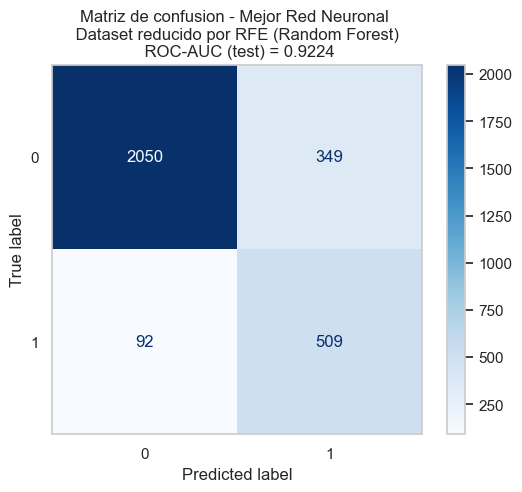

In [43]:
# 11. BÚSQUEDA DE HIPERPARÁMETROS PARA MLP (CON VARIABLES REDUCIDAS POR RFE)

from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import pandas as pd

from imblearn.over_sampling import SMOTE
# ¡IMPORTANTE! Importamos el Pipeline desde imblearn, NO desde sklearn
from imblearn.pipeline import Pipeline as ImbPipeline

preprocesador_final = ColumnTransformer(
    transformers=[
        ('escalar_num', numeric_transformer, num_features_final),
        ('codificar_cat', categorical_transformer, cat_features_final),
        ('imputar_bin', binary_transformer, bin_features_final),
    ],
    remainder='drop'
)

# 1. Creamos el pipeline SOLO con SMOTE y la Red Neuronal
# (Omite 'fe' y 'preprocesador' porque nuevo_df_train ya viene procesado)
nn_pipe_rfe = ImbPipeline(steps=[
    ('fe', transformer_feature_eng),
    ('preprocesador', preprocesador_final),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),  # Crea ejemplos sintéticos de la clase minoritaria
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

# 2. Grilla optimizada para ~12 a 15 variables de entrada
param_dist_rfe = {
    # Al tener menos variables, reducimos el tamaño de las capas para evitar sobreajuste
    'mlp__hidden_layer_sizes': [
        (32,), (64,),                 # 1 capa oculta: Rápidas y excelentes para datos tabulares
        (32, 16), (64, 32),           # 2 capas ocultas en embudo
        (64, 64),                     # 2 capas constantes
        (64, 32, 16), (32, 16, 8)     # 3 capas ocultas (límite recomendado)
    ],
    'mlp__activation': ['relu'],
    
    # Penalización L2 para controlar la colinealidad
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    
    # Tasas de aprendizaje para Adam
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    
    # Lotes de tamaño medio-grande para acelerar en CPU
    'mlp__batch_size': [32, 64, 128, 256]
}

# 3. Configuramos la búsqueda aleatoria
nn_search_rfe = RandomizedSearchCV(
    estimator=nn_pipe_rfe,       
    param_distributions=param_dist_rfe,
    n_iter=50,                   # Prueba 50 combinaciones al azar
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Iniciando búsqueda de hiperparámetros MLP con variables RFE...")
# 4. Entrenamos DIRECTAMENTE con el dataframe reducido que creaste
nn_search_rfe.fit(X_train, y_train)

print('\nMejor AUC CV:', round(nn_search_rfe.best_score_, 4))
print('Mejores hiperparámetros:')
for k, v in nn_search_rfe.best_params_.items():
    print(f'  - {k}: {v}')

# --- EVALUACIÓN EN EL CONJUNTO DE PRUEBA ---
# Calculamos predicciones y probabilidades usando el nuevo dataframe de test reducido
y_pred_rfe = nn_search_rfe.best_estimator_.predict(X_test)
y_pred_proba_rfe = nn_search_rfe.best_estimator_.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_pred_proba_rfe)

print(f"\n{'='*53}")
print(f"(ROC-AUC MLP Test = {auc_test:.4f})")
print(f"{'='*53}")
print(classification_report(y_test, y_pred_rfe))

cm_best = confusion_matrix(y_test, y_pred_rfe)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Red Neuronal \n Dataset reducido por RFE (Random Forest) \n ROC-AUC (test) = {:.4f}'.format(auc_test))
plt.grid(False)
plt.show()

### 8c) Regresion Logistica (dataset RFE)

In [44]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

# 1. Extraemos los nombres exactos de las variables ganadoras
variables_ganadoras = [
    nombre for nombre, seleccionado in zip(feature_names_final, rfecv_lr.support_) 
    if seleccionado
]

print(f"Total de variables seleccionadas: {len(variables_ganadoras)}")
print("Lista de variables:", variables_ganadoras)

# 2. Convertimos las matrices procesadas a DataFrame y filtramos solo las columnas ganadoras
X_train_reducido = pd.DataFrame(X_train_procesado, columns=feature_names_final)[variables_ganadoras]

# Transformamos también X_test usando el mismo pipeline anterior y filtramos
X_test_procesado = pipe_transformacion.transform(X_test)
X_test_reducido = pd.DataFrame(X_test_procesado, columns=feature_names_final)[variables_ganadoras]

# 3. Entrenamos el nuevo modelo de Regresión Logística SOLO con las variables ganadoras
modelo_lr_final = LogisticRegression(
    C=grid_RL_modif.best_params_['modelo__C'],  # Usamos el mejor C que habías encontrado
    random_state=42, 
    class_weight='balanced', 
    max_iter=1000
)

modelo_lr_final.fit(X_train_reducido, y_train)

# 4. Evaluamos con validación cruzada en Train y luego en Test real
auc_cv = cross_val_score(modelo_lr_final, X_train_reducido, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
y_pred_proba_test = modelo_lr_final.predict_proba(X_test_reducido)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"\nROC-AUC en Validación Cruzada (Train): {auc_cv:.4f}")
print(f"ROC-AUC en Test (Datos no vistos):     {auc_test:.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN EN TEST ---")
print(classification_report(y_test, modelo_lr_final.predict(X_test_reducido)))

 

Total de variables seleccionadas: 22
Lista de variables: ['escalar_num__Age', 'escalar_num__Tenure', 'escalar_num__Balance', 'escalar_num__BalancePerProduct', 'escalar_num__LoyaltyIndex', 'codificar_cat__Geography_Germany', 'codificar_cat__Gender_Male', 'codificar_cat__NumOfProducts_2.0', 'codificar_cat__NumOfProducts_3.0', 'codificar_cat__NumOfProducts_4.0', 'codificar_cat__AgeGroup_30-40', 'codificar_cat__AgeGroup_40-50', 'codificar_cat__AgeGroup_<30', 'codificar_cat__CreditScoreCategory_Medio', 'codificar_cat__CreditScoreCategory_Pobre', 'codificar_cat__Geography_x_Gender_France_Male', 'codificar_cat__Geography_x_Gender_Germany_Female', 'codificar_cat__Geography_x_Gender_Germany_Male', 'codificar_cat__Geography_x_Gender_Spain_Male', 'imputar_bin__IsSeniorCitizen', 'imputar_bin__HasBalance', 'imputar_bin__IsHighVolumeClient']

ROC-AUC en Validación Cruzada (Train): 0.9297
ROC-AUC en Test (Datos no vistos):     0.9220

--- REPORTE DE CLASIFICACIÓN EN TEST ---
              precision  

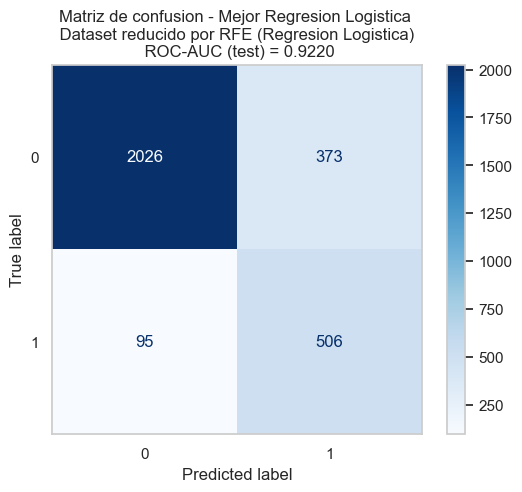

In [45]:
cm_best = confusion_matrix(y_test, y_pred_proba_test > 0.5)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor Regresion Logistica \n Dataset reducido por RFE (Regresion Logistica) \n ROC-AUC (test) = {:.4f}'.format(auc_test))
plt.grid(False)
plt.show()

## 9) Generación de archivo para submission en Kaggle

In [46]:
# Aseguramos que el pipeline (que incluye el feature engineering) prediga sobre df_test
# Como pipe_rf_modif incluye 'fe' (la función de ingeniería) y 'pre' (preprocesador),
# los datos de df_test serán transformados automáticamente igual que los de entrenamiento.
y_test_pred_proba = grid_rf_final.best_estimator_.predict_proba(df_test)[:, 1]

# Creamos el DataFrame de submission
# Kaggle solicita dos columnas: 'id' y 'Exited'
submission = pd.DataFrame({
    'id': test_ids,
    'Exited': y_test_pred_proba
})

# Guardamos el archivo
submission.to_csv('submission_modelo_final_rf.csv', index=False)

print("¡Archivo 'submission_modelo_final_rf.csv' generado con éxito!")
display(submission.head())

¡Archivo 'submission_modelo_final_rf.csv' generado con éxito!


,id,Exited
0,15000,0.04
1,15001,0.81
2,15002,0.08
3,15003,0.97
4,15004,0.22


Comentarios:  

- Entrenamos un modelo random forest con el dataset original que proviene de train.csv y obtuvimos un ROC AUC en test de 0.9246  
- Se incorporaron al modelo random forest un conjunto de variables sugeridas por el conocimiento experto y obtuvimos un ROC AUC 0.9224  
- Realizamos un análisis Recursive Feature Elimination (RFE), el cual sugirió eliminar 11 variables  
- Volvimos a entrenar el modelo random forest pero eliminando las 11 variables y obtuvimos un ROC AUC en test de 0.9239  
- Las diferencias obtenidas en el valor de ROC AUC muestran un rendimiento muy similar, si bien esperábamos encontrar un mejora importante al incorporar variables  
- A juzgar por estos resultados, estamos logrando casi el mismo poder predictivo con un modelo simple como el original.  
- Este resultado sorprende y de alguna manera nos lleva a meditar si hay algún error que estamos cometiendo.  